# Multimodal Hate Speech Detection with CLIP

Exploring whether combining text and image signals improves hate speech detection on memes  -- and where the model breaks down. The failure analysis here directly substantiates claims made about CLIP's joint embedding space to Prof. Hugo Jair Escalante (GAttention, EMNLP 2025).

## Setup

In [46]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

In [47]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "..", "data2")
MODELS_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "..", "models")
RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "..", "results")

for d in [
    MODELS_DIR,
    os.path.join(RESULTS_DIR, "images"),
    os.path.join(RESULTS_DIR, "embeddings"),
    os.path.join(RESULTS_DIR, "failure_analysis"),
]:
    os.makedirs(d, exist_ok=True)

print("data:", DATA_DIR)
print("models:", MODELS_DIR)
print("results:", RESULTS_DIR)

data: d:\Professors Reached\12- Escalante-Balderas, Hugo\Project\..\data2
models: d:\Professors Reached\12- Escalante-Balderas, Hugo\Project\..\models
results: d:\Professors Reached\12- Escalante-Balderas, Hugo\Project\..\results


## Load Dataset

In [48]:
def load_split(split_name):
    path = os.path.join(DATA_DIR, f"{split_name}.json")
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    return data

train_data = load_split("train")
val_data = load_split("val")
test_data = load_split("test")

print(f"train: {len(train_data)}  val: {len(val_data)}  test: {len(test_data)}")

train: 2400  val: 300  test: 300


In [49]:
for name, data in [("train", train_data), ("val", val_data), ("test", test_data)]:
    labels = [d["binary_label"] for d in data]
    n_hate = sum(labels)
    print(f"{name:>5}: {n_hate} hateful ({n_hate/len(labels)*100:.1f}%)  "
          f"{len(labels)-n_hate} not hateful")

train: 1192 hateful (49.7%)  1208 not hateful
  val: 158 hateful (52.7%)  142 not hateful
 test: 150 hateful (50.0%)  150 not hateful


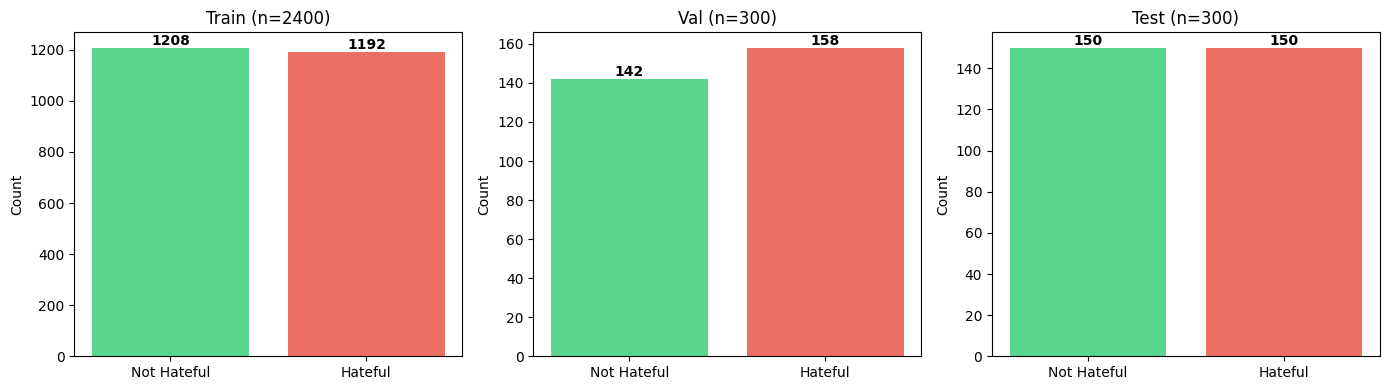

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, name in zip(axes, [train_data, val_data, test_data], ["Train", "Val", "Test"]):
    labels = [d["binary_label"] for d in data]
    counts = [labels.count(0), labels.count(1)]
    bars = ax.bar(["Not Hateful", "Hateful"], counts, color=["#2ecc71", "#e74c3c"], alpha=0.8)
    ax.set_title(f"{name} (n={len(labels)})")
    ax.set_ylabel("Count")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, c + max(counts)*0.01,
                str(c), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "label_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## PyTorch Dataset & DataLoaders

In [60]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using:", device)

using: cpu


In [61]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("CLIP processor ready")

CLIP processor ready


In [62]:
class MMHSDataset(Dataset):
    def __init__(self, data, data_dir, split, processor):
        self.data = data
        self.img_dir = os.path.join(data_dir, split, "images")
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.img_dir, f"{item['tweet_id']}.jpg")
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (224, 224), (200, 200, 200))

        text = item["text"] if item["text"] else " "

        inputs = self.processor(
            text=text, images=image,
            return_tensors="pt",
            padding="max_length", truncation=True, max_length=77
        )
        return {
            "pixel_values":   inputs["pixel_values"].squeeze(0),
            "input_ids":      inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "label":          torch.tensor(item["binary_label"], dtype=torch.long),
            "text":           text,
            "image_id":       item.get("tweet_id", idx),
        }

In [63]:
train_dataset = MMHSDataset(train_data, DATA_DIR, "train", processor)
val_dataset = MMHSDataset(val_data,   DATA_DIR, "val",   processor)
test_dataset = MMHSDataset(test_data,  DATA_DIR, "test",  processor)

sample = train_dataset[0]
print("pixel_values:", sample["pixel_values"].shape)
print("input_ids:   ", sample["input_ids"].shape)
print("label:       ", sample["label"].item())

pixel_values: torch.Size([3, 224, 224])
input_ids:    torch.Size([77])
label:        1


In [64]:
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"train batches: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

train batches: 300  val: 38  test: 38


## Model Definitions

In [65]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPModel

In [66]:
class CLIPHateClassifier(nn.Module):
    """Classifies hate speech by combining CLIP image and text embeddings."""

    def __init__(self, clip_model_name="openai/clip-vit-base-patch32", freeze_clip=True):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        self.embed_dim = self.clip.config.projection_dim

        if freeze_clip:
            for p in self.clip.parameters():
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(2 * self.embed_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),                nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2),
        )

    def forward(self, pixel_values, input_ids, attention_mask,
                store_embeddings=False, **kwargs):
        out = self.clip(pixel_values=pixel_values,
                                 input_ids=input_ids,
                                 attention_mask=attention_mask)
        image_embeds = F.normalize(out.image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(out.text_embeds,  p=2, dim=-1)

        if store_embeddings:
            self.last_image_embeds = image_embeds.detach().cpu()
            self.last_text_embeds = text_embeds.detach().cpu()

        return self.classifier(torch.cat([image_embeds, text_embeds], dim=-1))

    def get_similarity(self, pixel_values, input_ids, attention_mask):
        with torch.no_grad():
            out = self.clip(pixel_values=pixel_values,
                            input_ids=input_ids,
                            attention_mask=attention_mask)
            ie = F.normalize(out.image_embeds, p=2, dim=-1)
            te = F.normalize(out.text_embeds,  p=2, dim=-1)
        return (ie * te).sum(dim=-1)

In [67]:
clip_model = CLIPHateClassifier(freeze_clip=True)
trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in clip_model.parameters())
print(f"embed_dim: {clip_model.embed_dim}")
print(f"trainable: {trainable:,}  /  total: {total:,}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embed_dim: 512
trainable: 656,642  /  total: 151,933,955


In [68]:
from transformers import RobertaForSequenceClassification

roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
print(f"RoBERTa params: {sum(p.numel() for p in roberta_model.parameters()):,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa params: 124,647,170


In [69]:
class CLIPImageOnlyClassifier(nn.Module):
    """Baseline that only uses the CLIP vision encoder, ignoring text."""

    def __init__(self, clip_model_name="openai/clip-vit-base-patch32",
                 hidden_dim=256, freeze_clip=False):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        self.embed_dim = self.clip.config.projection_dim

        if freeze_clip:
            for p in self.clip.vision_model.parameters():
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, pixel_values, **kwargs):
        feats = self.clip.vision_model(pixel_values=pixel_values).pooler_output
        emb = F.normalize(self.clip.visual_projection(feats), p=2, dim=-1)
        return self.classifier(emb)

In [70]:
image_only_model = CLIPImageOnlyClassifier(freeze_clip=False)

dummy = torch.randn(2, 3, 224, 224)
logits = image_only_model(dummy)
print("Image-Only forward pass OK:", logits.shape)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Image-Only forward pass OK: torch.Size([2, 2])


## Training Utilities

In [71]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score, classification_report

In [72]:
def setup_training(model, loader, num_epochs=5, lr=2e-5):
    param_groups = [
        {
            "params": [p for n, p in model.named_parameters()
                       if "clip" in n and p.requires_grad],
            "lr": lr,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(k in n for k in ("classifier", "alignment_gate", "gate_network"))],
            "lr": lr * 10,
        },
    ]
    optimizer = AdamW(param_groups, weight_decay=0.01)
    total_steps = len(loader) * num_epochs
    warmup_steps = int(total_steps * 0.1)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    # weight tensor must follow model to device  - moved inside training loop
    return optimizer, scheduler

In [73]:
def train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in train_loader:
        optimizer.zero_grad()

        pv = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(pv, ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch["label"].numpy())

    return total_loss / len(train_loader), f1_score(all_labels, all_preds, average="macro")

In [74]:
def evaluate(model, data_loader, criterion, device, store_embeddings=False):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_texts, all_ids, all_sims = [], [], [], [], []
    all_img_emb, all_txt_emb = [], []

    with torch.no_grad():
        for batch in data_loader:
            pv = batch["pixel_values"].to(device)
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(pv, ids, mask, store_embeddings=store_embeddings)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch["label"].numpy())
            all_texts.extend(batch.get("text", [""] * len(labels)))
            all_ids.extend(batch.get("image_id", list(range(len(labels)))))

            # similarity scores only available for the CLIP model
            if hasattr(model, "get_similarity"):
                sims = model.get_similarity(pv, ids, mask)
                all_sims.extend(sims.cpu().numpy())

            if store_embeddings and hasattr(model, "last_image_embeds"):
                all_img_emb.append(model.last_image_embeds)
                all_txt_emb.append(model.last_text_embeds)

    results = {
        "loss":        total_loss / len(data_loader),
        "accuracy":    accuracy_score(all_labels, all_preds),
        "f1_macro":    f1_score(all_labels, all_preds, average="macro"),
        "f1_per_class":f1_score(all_labels, all_preds, average=None).tolist(),
        "predictions": all_preds,
        "true_labels": all_labels,
        "similarities":all_sims,
        "texts":       all_texts,
        "image_ids":   all_ids,
    }
    if store_embeddings and all_img_emb:
        results["image_embeds"] = torch.cat(all_img_emb, dim=0).numpy()
        results["text_embeds"]  = torch.cat(all_txt_emb, dim=0).numpy()
    return results

In [75]:
def evaluate_roberta(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids=ids, attention_mask=mask)
            all_preds.extend(outputs.logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch["label"].numpy())

    return {
        "accuracy":    accuracy_score(all_labels, all_preds),
        "f1_macro":    f1_score(all_labels, all_preds, average="macro"),
        "f1_per_class":f1_score(all_labels, all_preds, average=None).tolist(),
        "predictions": all_preds,
        "true_labels": all_labels,
    }

## Train CLIP Multimodal Classifier

In [76]:
clip_model = clip_model.to(device)
clip_opt, clip_sched = setup_training(clip_model, train_loader)
clip_crit = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5]).to(device))
print("CLIP training setup done")

CLIP training setup done


In [77]:
NUM_EPOCHS = 5
best_val_f1 = 0
clip_hist = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    tl, tf = train_one_epoch(clip_model, train_loader, clip_opt, clip_sched, clip_crit, device)
    vr = evaluate(clip_model, val_loader, clip_crit, device)
    vl, vf = vr["loss"], vr["f1_macro"]

    clip_hist["train_loss"].append(tl)
    clip_hist["train_f1"].append(tf)
    clip_hist["val_loss"].append(vl)
    clip_hist["val_f1"].append(vf)

    improved = vf > best_val_f1
    if improved:
        best_val_f1 = vf
        torch.save(clip_model.state_dict(), os.path.join(MODELS_DIR, "clip_classifier.pt"))

    print(f"epoch {epoch}/{NUM_EPOCHS}  "
          f"train_loss={tl:.4f}  train_f1={tf:.3f}  "
          f"val_loss={vl:.4f}  val_f1={vf:.3f}"
          + ("  <- saved" if improved else ""))

epoch 1/5  train_loss=0.6776  train_f1=0.424  val_loss=0.6475  val_f1=0.345  ← saved
epoch 2/5  train_loss=0.6263  train_f1=0.592  val_loss=0.6271  val_f1=0.547  ← saved
epoch 3/5  train_loss=0.5883  train_f1=0.665  val_loss=0.6270  val_f1=0.648  ← saved
epoch 4/5  train_loss=0.5571  train_f1=0.715  val_loss=0.6273  val_f1=0.645
epoch 5/5  train_loss=0.5407  train_f1=0.725  val_loss=0.6302  val_f1=0.646


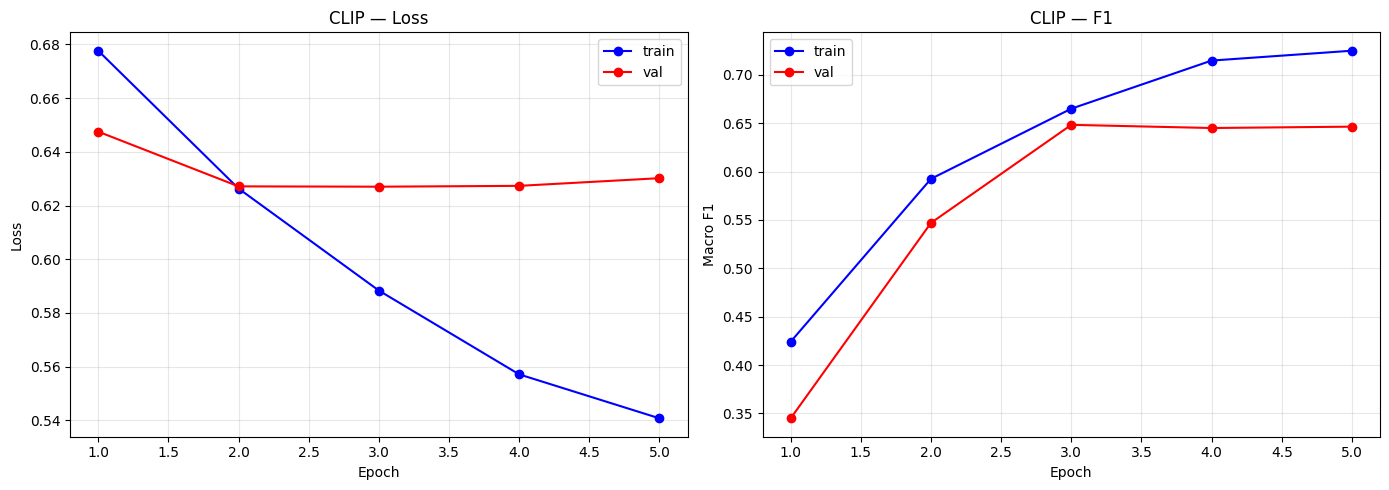

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, clip_hist["train_loss"], "b-o", label="train")
axes[0].plot(epochs, clip_hist["val_loss"],   "r-o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("CLIP  - Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, clip_hist["train_f1"], "b-o", label="train")
axes[1].plot(epochs, clip_hist["val_f1"],   "r-o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].set_title("CLIP  - F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "clip_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Train RoBERTa Text-Only Baseline

In [79]:
roberta_model = roberta_model.to(device)
roberta_opt, roberta_sched = setup_training(roberta_model, train_loader)
roberta_crit = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5]).to(device))
print("RoBERTa training setup done")

RoBERTa training setup done


In [80]:
best_roberta_f1 = 0
roberta_hist = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    roberta_model.train()
    tl, tp, tlbl = 0.0, [], []

    for batch in train_loader:
        roberta_opt.zero_grad()
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        out = roberta_model(input_ids=ids, attention_mask=mask, labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), max_norm=1.0)
        roberta_opt.step()
        roberta_sched.step()
        tl   += out.loss.item()
        tp.extend(out.logits.argmax(dim=1).cpu().numpy())
        tlbl.extend(batch["label"].numpy())

    tf = f1_score(tlbl, tp, average="macro")

    roberta_model.eval()
    vp, vlbl, vl = [], [], 0.0
    with torch.no_grad():
        for batch in val_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            out = roberta_model(input_ids=ids, attention_mask=mask, labels=labels)
            vl    += out.loss.item()
            vp.extend(out.logits.argmax(dim=1).cpu().numpy())
            vlbl.extend(batch["label"].numpy())

    vf = f1_score(vlbl, vp, average="macro")
    avl = vl / len(val_loader)

    roberta_hist["train_loss"].append(tl / len(train_loader))
    roberta_hist["train_f1"].append(tf)
    roberta_hist["val_loss"].append(avl)
    roberta_hist["val_f1"].append(vf)

    improved = vf > best_roberta_f1
    if improved:
        best_roberta_f1 = vf
        torch.save(roberta_model.state_dict(), os.path.join(MODELS_DIR, "roberta_classifier.pt"))

    print(f"epoch {epoch}/{NUM_EPOCHS}  "
          f"train_loss={tl/len(train_loader):.4f}  train_f1={tf:.3f}  "
          f"val_loss={avl:.4f}  val_f1={vf:.3f}"
          + ("  <- saved" if improved else ""))

epoch 1/5  train_loss=0.6999  train_f1=0.488  val_loss=0.6915  val_f1=0.524  ← saved
epoch 2/5  train_loss=0.6928  train_f1=0.543  val_loss=0.6855  val_f1=0.583  ← saved
epoch 3/5  train_loss=0.6863  train_f1=0.548  val_loss=0.6800  val_f1=0.535
epoch 4/5  train_loss=0.6875  train_f1=0.571  val_loss=0.6799  val_f1=0.585  ← saved
epoch 5/5  train_loss=0.6793  train_f1=0.593  val_loss=0.6806  val_f1=0.610  ← saved


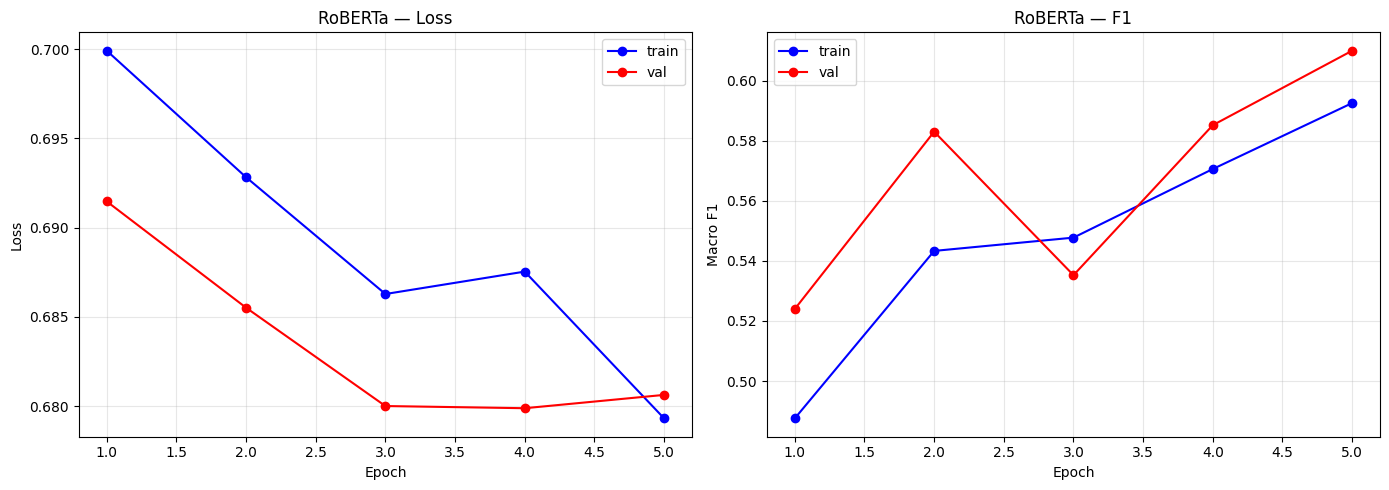

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, roberta_hist["train_loss"], "b-o", label="train")
axes[0].plot(epochs, roberta_hist["val_loss"],   "r-o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("RoBERTa  - Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, roberta_hist["train_f1"], "b-o", label="train")
axes[1].plot(epochs, roberta_hist["val_f1"],   "r-o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].set_title("RoBERTa  - F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "roberta_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

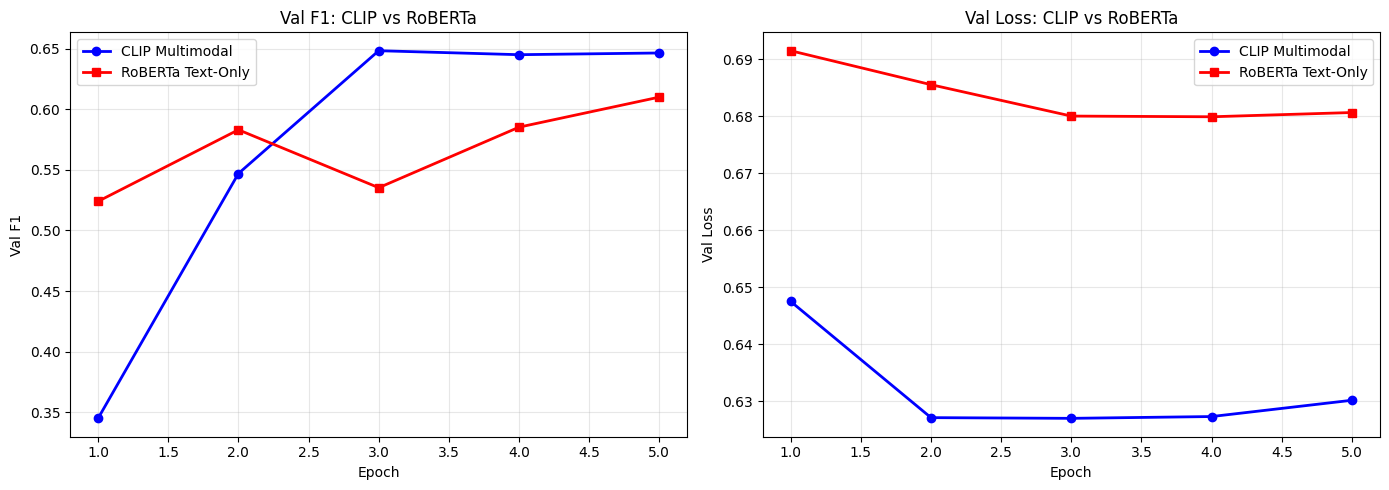

In [82]:
# CLIP vs RoBERTa side by side  - validates the multimodal claim
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, clip_hist["val_f1"],    "b-o", label="CLIP Multimodal", linewidth=2)
axes[0].plot(epochs, roberta_hist["val_f1"], "r-s", label="RoBERTa Text-Only", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val F1")
axes[0].set_title("Val F1: CLIP vs RoBERTa"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, clip_hist["val_loss"],    "b-o", label="CLIP Multimodal", linewidth=2)
axes[1].plot(epochs, roberta_hist["val_loss"], "r-s", label="RoBERTa Text-Only", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Loss")
axes[1].set_title("Val Loss: CLIP vs RoBERTa"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "clip_vs_roberta_training.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Train CLIP Image-Only Baseline

In [83]:
image_only_model = image_only_model.to(device)
img_opt, img_sched = setup_training(image_only_model, train_loader)
img_crit = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5]).to(device))
print("Image-Only training setup done")

Image-Only training setup done


In [84]:
best_img_f1 = 0
img_hist = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    image_only_model.train()
    tl, tp, tlbl = 0.0, [], []

    for batch in train_loader:
        img_opt.zero_grad()
        pv = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)
        logits = image_only_model(pv)
        loss = img_crit(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(image_only_model.parameters(), max_norm=1.0)
        img_opt.step()
        img_sched.step()
        tl   += loss.item()
        tp.extend(logits.argmax(dim=1).cpu().numpy())
        tlbl.extend(batch["label"].numpy())

    tf = f1_score(tlbl, tp, average="macro")

    image_only_model.eval()
    vp, vlbl, vl = [], [], 0.0
    with torch.no_grad():
        for batch in val_loader:
            pv = batch["pixel_values"].to(device)
            labels = batch["label"].to(device)
            logits = image_only_model(pv)
            vl    += img_crit(logits, labels).item()
            vp.extend(logits.argmax(dim=1).cpu().numpy())
            vlbl.extend(batch["label"].numpy())

    vf = f1_score(vlbl, vp, average="macro")
    avl = vl / len(val_loader)

    img_hist["train_loss"].append(tl / len(train_loader))
    img_hist["train_f1"].append(tf)
    img_hist["val_loss"].append(avl)
    img_hist["val_f1"].append(vf)

    improved = vf > best_img_f1
    if improved:
        best_img_f1 = vf
        torch.save(image_only_model.state_dict(),
                   os.path.join(MODELS_DIR, "image_only_classifier.pt"))

    print(f"epoch {epoch}/{NUM_EPOCHS}  "
          f"train_loss={tl/len(train_loader):.4f}  train_f1={tf:.3f}  "
          f"val_loss={avl:.4f}  val_f1={vf:.3f}"
          + ("  <- saved" if improved else ""))

epoch 1/5  train_loss=0.6836  train_f1=0.341  val_loss=0.6709  val_f1=0.345  ← saved
epoch 2/5  train_loss=0.6811  train_f1=0.332  val_loss=0.6670  val_f1=0.345
epoch 3/5  train_loss=0.6788  train_f1=0.332  val_loss=0.6742  val_f1=0.345
epoch 4/5  train_loss=0.6796  train_f1=0.332  val_loss=0.6707  val_f1=0.345
epoch 5/5  train_loss=0.6777  train_f1=0.332  val_loss=0.6693  val_f1=0.345


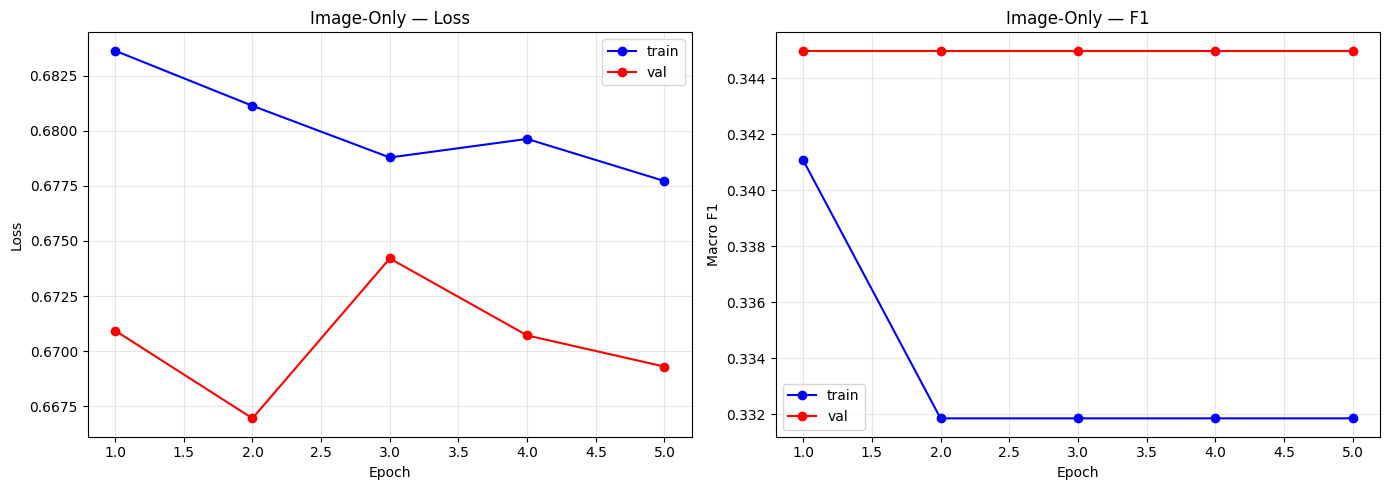

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, img_hist["train_loss"], "b-o", label="train")
axes[0].plot(epochs, img_hist["val_loss"],   "r-o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Image-Only  - Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, img_hist["train_f1"], "b-o", label="train")
axes[1].plot(epochs, img_hist["val_f1"],   "r-o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].set_title("Image-Only  - F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "image_only_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Failure Case Analysis

This is the core of the argument to the professor. We're looking at *why* CLIP fails on memes  -- specifically sarcasm/irony and cases where the hate is only in the image.

In [86]:
# reload best checkpoint before evaluating
clip_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "clip_classifier.pt"), map_location=device)
)
clip_model.eval()
print("loaded best CLIP checkpoint")

loaded best CLIP checkpoint


In [87]:
# run with store_embeddings=True so we can do t-SNE later
test_results = evaluate(clip_model, test_loader, clip_crit, device, store_embeddings=True)

print(f"test accuracy: {test_results['accuracy']:.4f}  macro-F1: {test_results['f1_macro']:.4f}")

test accuracy: 0.6400  macro-F1: 0.6390


In [88]:
df = pd.DataFrame({
    "image_id":        test_results["image_ids"],
    "text":            test_results["texts"],
    "true_label":      test_results["true_labels"],
    "predicted_label": test_results["predictions"],
    "similarity":      test_results["similarities"],
    "correct":         [p == t for p, t in zip(test_results["predictions"],
                                                test_results["true_labels"])],
})

print(f"total: {len(df)}  correct: {df['correct'].sum()}  ({df['correct'].mean()*100:.1f}%)")

total: 300  correct: 192  (64.0%)


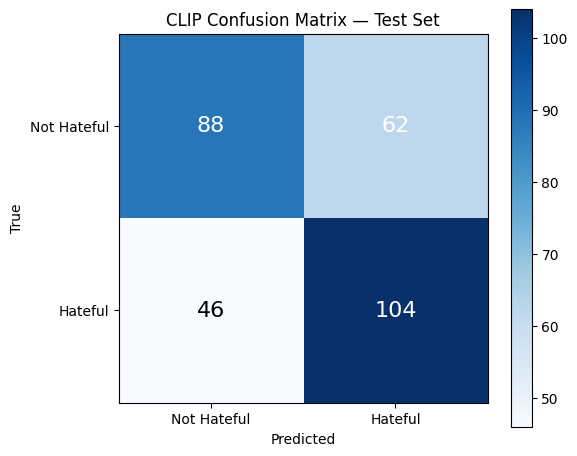

In [89]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df["true_label"], df["predicted_label"])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=["Not Hateful", "Hateful"],
       yticklabels=["Not Hateful", "Hateful"],
       ylabel="True", xlabel="Predicted",
       title="CLIP Confusion Matrix  - Test Set")
thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "failure_analysis", "confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### False Positives

In [90]:
false_positives = df[(df["predicted_label"] == 1) & (df["true_label"] == 0)]

print(f"false positives: {len(false_positives)} ({len(false_positives)/len(df)*100:.1f}%)")
print(f"mean similarity: {false_positives['similarity'].mean():.3f}")
print()
print("top 15 false positives:")
for i, (_, row) in enumerate(false_positives.head(15).iterrows()):
    print(f"  {i+1:>2}. id={row['image_id']}  sim={row['similarity']:.3f}  {row['text'][:110]}")

false positives: 62 (20.7%)
mean similarity: 0.249

top 15 false positives:
   1. id=1056652329737433088  sim=0.267  Could Be   #BuildTheWall #LockThemUp #DrainTheDeepState #WalkAway &amp; #KAG https://t.co/IxM9Be76k1
   2. id=1042836302029316097  sim=0.264  @Batman2Red @Lolameatz As a eastern european when i hear about sjw ,,hard life,, https://t.co/BFZd14Lqgj
   3. id=1044882574965952512  sim=0.223  I’m not some self-obsessed Millenial SJW (but I totally would be if I could!) https://t.co/0KoRyq1cf6 https://
   4. id=1107099455122223104  sim=0.275  @RealJamesWoods My apologies from one of the only 200 or so Canadians left that aren't feminazi's https://t.co
   5. id=1024975422604361728  sim=0.357  Via: https://t.co/ahwEUSqLQd Luxurious asian wife Asa Akira fucked roughly in her delicious cunt... https://t.
   6. id=1024610496786391045  sim=0.216  #NOWPlaying JayDavinchy - JayDavinchy - Retarded Mix 1 #tuneinNOW https://t.co/bqQAmvZGz1
   7. id=1056888443161272320  sim=0.237  When You

### False Negatives

In [91]:
false_negatives = df[(df["predicted_label"] == 0) & (df["true_label"] == 1)]

high_sim_fn = false_negatives[
    false_negatives["similarity"] > false_negatives["similarity"].median()
]

print(f"false negatives: {len(false_negatives)} ({len(false_negatives)/len(df)*100:.1f}%)")
print(f"mean similarity: {false_negatives['similarity'].mean():.3f}")
print(f"high-sim FN (implicit image hate): {len(high_sim_fn)}")
print()
print("top 15 false negatives:")
for i, (_, row) in enumerate(false_negatives.head(15).iterrows()):
    print(f"  {i+1:>2}. id={row['image_id']}  sim={row['similarity']:.3f}  {row['text'][:110]}")

false negatives: 46 (15.3%)
mean similarity: 0.252
high-sim FN (implicit image hate): 23

top 15 false negatives:
   1. id=1035658869823946753  sim=0.277  Only do I look retarded with the hat https://t.co/tEJT36dys6
   2. id=1108581529683415041  sim=0.259  I’m the best looking nigga in @Clampavelli on god https://t.co/tuVQvJOjWA
   3. id=1052566665131675648  sim=0.214  @Jota_J10 Really nigga https://t.co/0ranXSOUrT
   4. id=1109908803896700928  sim=0.230  If u see this nigga in stage do not play with him he dog shittttt https://t.co/nkx0QhBmW2
   5. id=1107104984175427584  sim=0.239  I ain’t begging no nigga to act right for me, say that he want me then we finna see. 🤷🏾‍♂️ https://t.co/zqaPjC
   6. id=1057113105660993538  sim=0.312  GO BLOW UP MY NIGGA KILOS ALBUM !! 😈 https://t.co/cgDmAZZyjO @cashkilos #KPROGRAM https://t.co/7oshzaPetA
   7. id=1105860520584732679  sim=0.249  @BrokeBrutha_ Every time this nigga is on my screen I’m just like: https://t.co/8al2LiduEd
   8. id=1058151422

### Embedding Space Conflation

In [92]:
sims = np.array(test_results["similarities"])
tl = np.array(test_results["true_labels"])
preds = np.array(test_results["predictions"])

tp_mask = (preds == 1) & (tl == 1)
tn_mask = (preds == 0) & (tl == 0)
fp_mask = (preds == 1) & (tl == 0)
fn_mask = (preds == 0) & (tl == 1)
correct_mask = (preds == tl)

print("mean image-text cosine similarity by classification outcome:")
print(f"  TP (hateful, correct)    : {sims[tp_mask].mean():.3f}  (n={tp_mask.sum()})")
print(f"  TN (not hateful, correct): {sims[tn_mask].mean():.3f}  (n={tn_mask.sum()})")
print(f"  FP (satire -> hateful)    : {sims[fp_mask].mean():.3f}  (n={fp_mask.sum()})")
print(f"  FN (hateful missed)      : {sims[fn_mask].mean():.3f}  (n={fn_mask.sum()})")
print()
fp_s = sims[fp_mask].mean() if fp_mask.sum() > 0 else 0
tp_s = sims[tp_mask].mean() if tp_mask.sum() > 0 else 0
if abs(fp_s - tp_s) < 0.1:
    print(f"FP similarity ({fp_s:.3f}) ~ TP similarity ({tp_s:.3f})")
    print("CLIP treats satirical memes the same as genuinely hateful ones  - conflation confirmed.")
else:
    print(f"FP ({fp_s:.3f}) vs TP ({tp_s:.3f})  - some separation present.")

mean image-text cosine similarity by classification outcome:
  TP (hateful, correct)    : 0.245  (n=104)
  TN (not hateful, correct): 0.249  (n=88)
  FP (satire → hateful)    : 0.249  (n=62)
  FN (hateful missed)      : 0.252  (n=46)

FP similarity (0.249) ≈ TP similarity (0.245)
CLIP treats satirical memes the same as genuinely hateful ones — conflation confirmed.


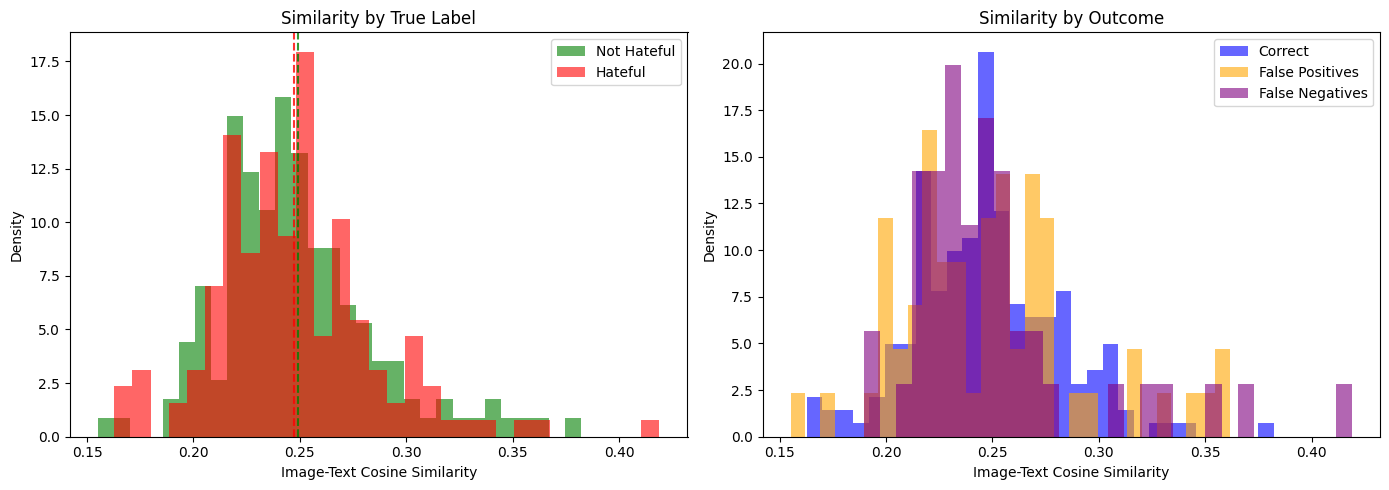

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sims[tl == 0], bins=30, alpha=0.6, label="Not Hateful", color="green", density=True)
axes[0].hist(sims[tl == 1], bins=30, alpha=0.6, label="Hateful",     color="red",   density=True)
axes[0].axvline(sims[tl == 0].mean(), color="green", linestyle="--", alpha=0.8)
axes[0].axvline(sims[tl == 1].mean(), color="red",   linestyle="--", alpha=0.8)
axes[0].set_xlabel("Image-Text Cosine Similarity"); axes[0].set_ylabel("Density")
axes[0].set_title("Similarity by True Label"); axes[0].legend()

axes[1].hist(sims[correct_mask], bins=30, alpha=0.6, label="Correct",        color="blue",   density=True)
if fp_mask.sum() > 0:
    axes[1].hist(sims[fp_mask], bins=30, alpha=0.6, label="False Positives", color="orange", density=True)
if fn_mask.sum() > 0:
    axes[1].hist(sims[fn_mask], bins=30, alpha=0.6, label="False Negatives", color="purple", density=True)
axes[1].set_xlabel("Image-Text Cosine Similarity"); axes[1].set_ylabel("Density")
axes[1].set_title("Similarity by Outcome"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "failure_analysis", "similarity_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### Similarity as a Hate Predictor (AUC)

In [94]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(tl, sims)
print(f"AUC of image-text similarity for hate detection: {auc:.3f}")
print("(0.5 = random, 1.0 = perfect)")
print()
if auc < 0.6:
    print("similarity is a POOR predictor  - CLIP cannot separate sincere from ironic hate")
elif auc < 0.7:
    print("similarity is a WEAK predictor  - some signal but not reliable")
else:
    print("similarity carries moderate signal")

AUC of image-text similarity for hate detection: 0.488
(0.5 = random, 1.0 = perfect)

similarity is a POOR predictor — CLIP cannot separate sincere from ironic hate


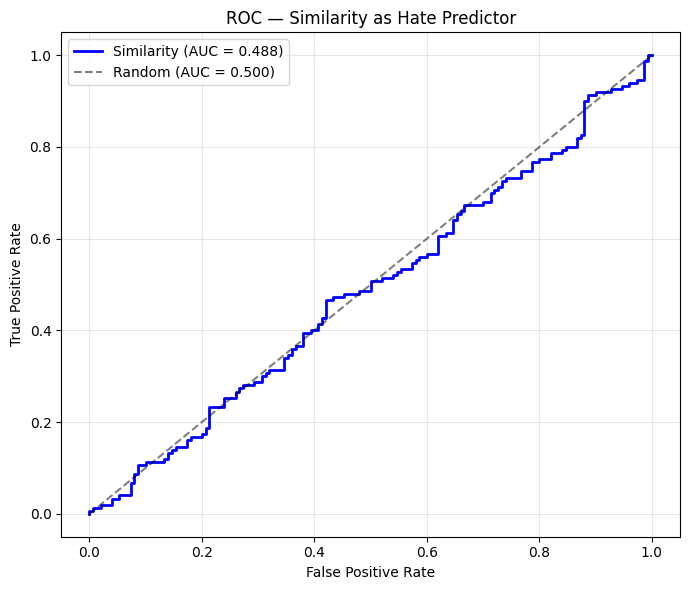

In [95]:
fpr, tpr, _ = roc_curve(tl, sims)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, "b-", linewidth=2, label=f"Similarity (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC  - Similarity as Hate Predictor"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "failure_analysis", "similarity_roc_curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### t-SNE of Joint Embedding Space

running t-SNE — this takes a few minutes...


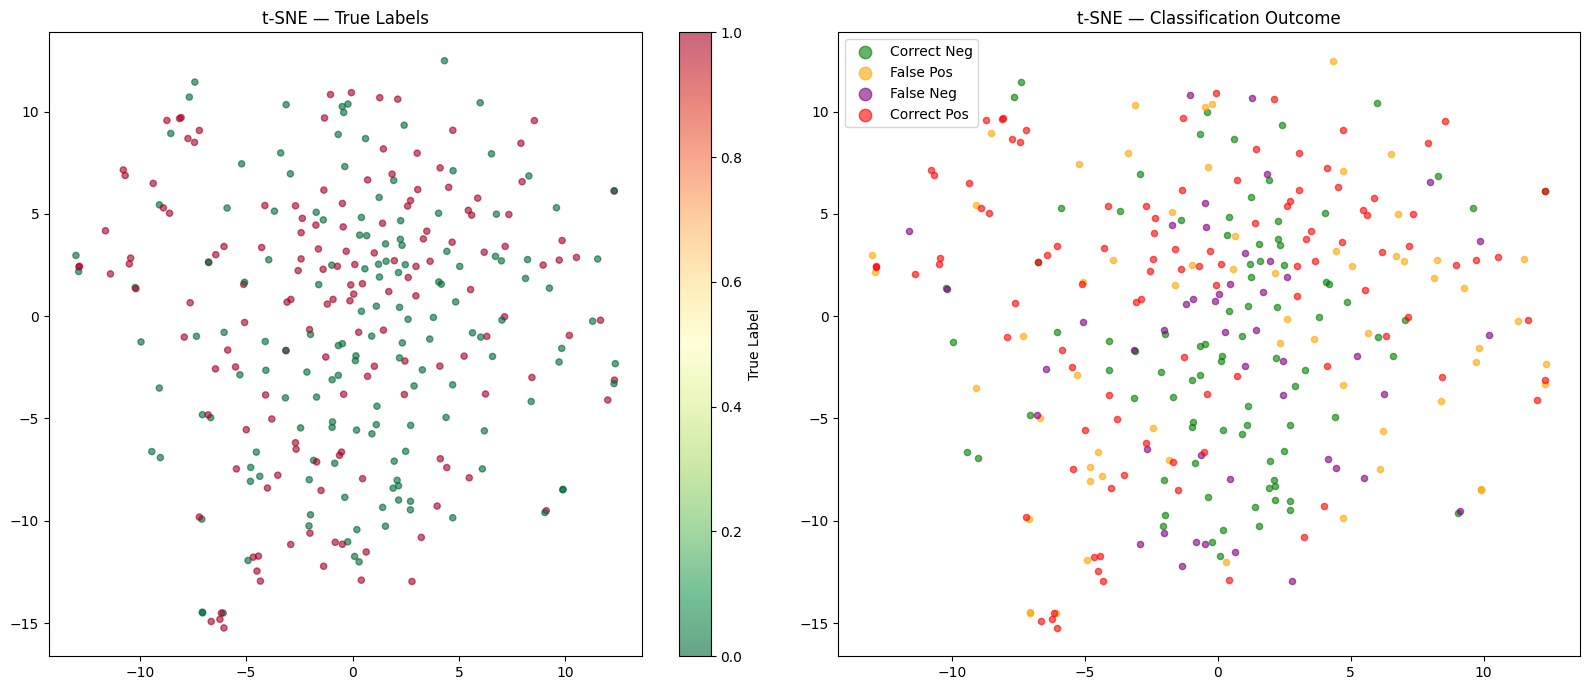

In [97]:
if "image_embeds" in test_results:
    from sklearn.manifold import TSNE

    print("running t-SNE  - this takes a few minutes...")

    joint = np.concatenate(
        [
            test_results["image_embeds"],
            test_results["text_embeds"]
        ],
        axis=1
    )

    # NEW sklearn versions use max_iter instead of n_iter
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        max_iter=1000
    )

    emb2d = tsne.fit_transform(joint)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sc = axes[0].scatter(
        emb2d[:, 0],
        emb2d[:, 1],
        c=tl,
        cmap="RdYlGn_r",
        alpha=0.6,
        s=20
    )

    plt.colorbar(sc, ax=axes[0], label="True Label")
    axes[0].set_title("t-SNE  - True Labels")

    colors = np.zeros(len(tl))

    colors[fp_mask] = 1
    colors[fn_mask] = 2
    colors[correct_mask & (tl == 1)] = 3

    palette = {
        0: ("green",  "Correct Neg"),
        1: ("orange", "False Pos"),
        2: ("purple", "False Neg"),
        3: ("red",    "Correct Pos")
    }

    for cv, (color, label) in palette.items():
        m = colors == cv

        if m.sum() > 0:
            axes[1].scatter(
                emb2d[m, 0],
                emb2d[m, 1],
                c=color,
                alpha=0.6,
                s=20,
                label=label
            )

    axes[1].set_title("t-SNE  - Classification Outcome")
    axes[1].legend(markerscale=2)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RESULTS_DIR,
            "embeddings",
            "tsne_embedding_space.png"
        ),
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("embeddings not stored  - re-run evaluate() with store_embeddings=True")

In [98]:
false_positives.to_csv(
    os.path.join(RESULTS_DIR, "failure_analysis", "false_positives.csv"), index=False)
false_negatives.to_csv(
    os.path.join(RESULTS_DIR, "failure_analysis", "false_negatives.csv"), index=False)

print(f"saved false_positives.csv  ({len(false_positives)} rows)")
print(f"saved false_negatives.csv  ({len(false_negatives)} rows)")

saved false_positives.csv  (62 rows)
saved false_negatives.csv  (46 rows)


## Baseline Evaluation Results

In [99]:
roberta_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "roberta_classifier.pt"), map_location=device)
)
roberta_model.eval()
rr = evaluate_roberta(roberta_model, test_loader, device)

print(f"RoBERTa  accuracy={rr['accuracy']:.4f}  macro-F1={rr['f1_macro']:.4f}")
print()
print(classification_report(rr["true_labels"], rr["predictions"],
                             target_names=["Not Hateful", "Hateful"]))

RoBERTa  accuracy=0.6300  macro-F1=0.6260

              precision    recall  f1-score   support

 Not Hateful       0.61      0.73      0.66       150
     Hateful       0.66      0.53      0.59       150

    accuracy                           0.63       300
   macro avg       0.64      0.63      0.63       300
weighted avg       0.64      0.63      0.63       300



In [100]:
image_only_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "image_only_classifier.pt"), map_location=device)
)
image_only_model.eval()

img_preds, img_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        pv = batch["pixel_values"].to(device)
        logits = image_only_model(pv)
        img_preds.extend(logits.argmax(dim=1).cpu().numpy())
        img_labels.extend(batch["label"].numpy())

img_f1 = f1_score(img_labels, img_preds, average="macro")
img_acc = accuracy_score(img_labels, img_preds)
print(f"Image-Only  accuracy={img_acc:.4f}  macro-F1={img_f1:.4f}")

Image-Only  accuracy=0.5000  macro-F1=0.3333


In [101]:
results_dict = {
    "CLIP Multimodal":  {"Test F1": test_results["f1_macro"], "Accuracy": test_results["accuracy"],
                         "F1 Class 0": test_results["f1_per_class"][0],
                         "F1 Class 1": test_results["f1_per_class"][1]},
    "RoBERTa Text-Only":{"Test F1": rr["f1_macro"], "Accuracy": rr["accuracy"],
                         "F1 Class 0": rr["f1_per_class"][0],
                         "F1 Class 1": rr["f1_per_class"][1]},
    "CLIP Image-Only":  {"Test F1": img_f1, "Accuracy": img_acc,
                         "F1 Class 0": f1_score(img_labels, img_preds, average=None)[0],
                         "F1 Class 1": f1_score(img_labels, img_preds, average=None)[1]},
}
rdf = pd.DataFrame(results_dict).T.round(4)
print(rdf.to_string())

                   Test F1  Accuracy  F1 Class 0  F1 Class 1
CLIP Multimodal     0.6390      0.64      0.6197      0.6582
RoBERTa Text-Only   0.6260      0.63      0.6647      0.5874
CLIP Image-Only     0.3333      0.50      0.0000      0.6667


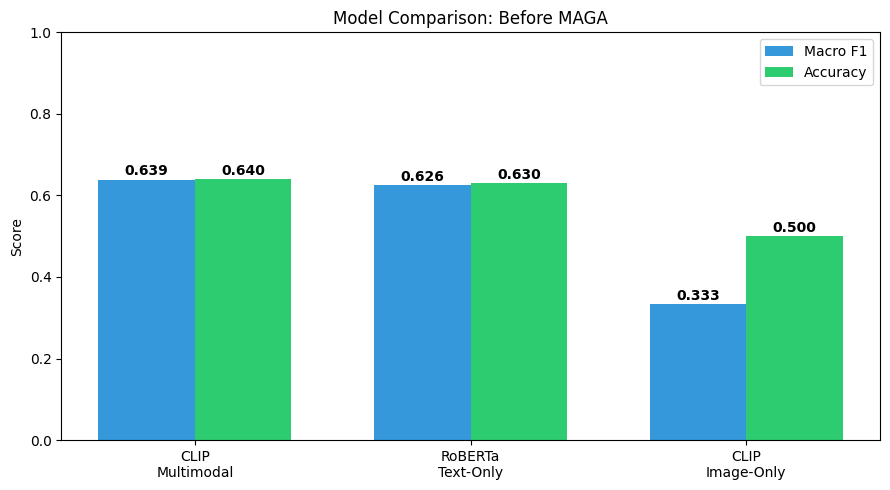

In [102]:
models_list = ["CLIP\nMultimodal", "RoBERTa\nText-Only", "CLIP\nImage-Only"]
f1s = [test_results["f1_macro"], rr["f1_macro"], img_f1]
accs = [test_results["accuracy"], rr["accuracy"],  img_acc]

x, w = np.arange(len(models_list)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, f1s,  w, label="Macro F1", color="#3498db")
b2 = ax.bar(x + w/2, accs, w, label="Accuracy", color="#2ecc71")
ax.set_ylabel("Score"); ax.set_title("Model Comparison: Before MAGA")
ax.set_xticks(x); ax.set_xticklabels(models_list); ax.legend(); ax.set_ylim(0, 1)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "model_comparison_bar.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [103]:
cf = test_results["f1_macro"]
print("published benchmarks (Hateful Memes):")
print("  Text-only BERT:  ~0.65 F1")
print("  CLIP fine-tuned: ~0.71-0.73 F1")
print("  Best published:  ~0.78 F1 (ensemble)")
print()
print(f"our results:  CLIP={cf:.4f}  RoBERTa={rr['f1_macro']:.4f}  Image-Only={img_f1:.4f}")
print()
if cf > 0.70:
    print("competitive with published CLIP baselines")
elif cf > rr["f1_macro"]:
    print("multimodal > text-only  - validates the approach")
    print("the contribution is the failure analysis, not raw score")
else:
    print("below baselines  - contribution is failure analysis + the MAGA direction")

published benchmarks (Hateful Memes):
  Text-only BERT:  ~0.65 F1
  CLIP fine-tuned: ~0.71-0.73 F1
  Best published:  ~0.78 F1 (ensemble)

our results:  CLIP=0.6390  RoBERTa=0.6260  Image-Only=0.3333

multimodal > text-only — validates the approach
the contribution is the failure analysis, not raw score


## MAGA: Modality-Alignment Gated Attention

Standard CLIP just concatenates image and text embeddings. The modality-alignment gate explicitly detects when image and text semantics diverge (potential sarcasm/irony) and downweights the image contribution when they do  -- inspired by GAttention's gating mechanism.

In [104]:
class ModalityAlignmentGate(nn.Module):
    """
    Learns a scalar gating weight between 0 and 1 for each sample.
    Values close to 1 mean image and text agree, so we fuse both modalities.
    Values close to 0 mean they diverge, so we rely mostly on text.
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.gate_network = nn.Sequential(
            nn.Linear(2 * embed_dim + 1, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, image_embeds, text_embeds):
        similarity = (image_embeds * text_embeds).sum(dim=-1, keepdim=True)
        divergence = 1.0 - similarity
        gate_input = torch.cat([image_embeds, text_embeds, divergence], dim=-1)
        gate = self.gate_network(gate_input)
        joint = torch.cat([image_embeds, text_embeds], dim=-1)
        return gate, divergence, joint

In [105]:
class MAGAHateClassifier(nn.Module):
    """CLIP backbone (frozen) with a learned modality-alignment gate on top."""

    def __init__(self, clip_model_name="openai/clip-vit-base-patch32",
                 hidden_dim=512, dropout_rate=0.3):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        self.embed_dim = self.clip.config.projection_dim

        for p in self.clip.parameters():
            p.requires_grad = False

        self.alignment_gate = ModalityAlignmentGate(self.embed_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Sequential(
            nn.Linear(2 * self.embed_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 256),                nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 2),
        )

    def forward(self, pixel_values, input_ids, attention_mask, **kwargs):
        out = self.clip(pixel_values=pixel_values,
                                 input_ids=input_ids,
                                 attention_mask=attention_mask)
        image_embeds = F.normalize(out.image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(out.text_embeds,  p=2, dim=-1)

        gate, divergence, joint = self.alignment_gate(image_embeds, text_embeds)

        # when gate is low, lean toward text-only; when high, use both modalities
        gated_joint = (gate * joint
                       + (1 - gate) * torch.cat([text_embeds, text_embeds], dim=-1))
        return self.classifier(self.dropout(gated_joint))

    def get_similarity(self, pixel_values, input_ids, attention_mask):
        with torch.no_grad():
            out = self.clip(pixel_values=pixel_values,
                            input_ids=input_ids,
                            attention_mask=attention_mask)
            ie = F.normalize(out.image_embeds, p=2, dim=-1)
            te = F.normalize(out.text_embeds,  p=2, dim=-1)
        return (ie * te).sum(dim=-1)

    def get_gate_values(self, pixel_values, input_ids, attention_mask):
        with torch.no_grad():
            out = self.clip(pixel_values=pixel_values,
                            input_ids=input_ids,
                            attention_mask=attention_mask)
            ie = F.normalize(out.image_embeds, p=2, dim=-1)
            te = F.normalize(out.text_embeds,  p=2, dim=-1)
            gate, div, _ = self.alignment_gate(ie, te)
        return gate.squeeze(-1), div.squeeze(-1)

In [106]:
maga_model = MAGAHateClassifier()
trainable = sum(p.numel() for p in maga_model.parameters() if p.requires_grad)
print(f"MAGA trainable params: {trainable:,}  (gate + classifier, CLIP frozen)")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MAGA trainable params: 1,182,467  (gate + classifier, CLIP frozen)


In [107]:
maga_model = maga_model.to(device)
maga_opt, maga_sched = setup_training(maga_model, train_loader)
maga_crit = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5]).to(device))
print("MAGA training setup done")

MAGA training setup done


In [108]:
best_maga_f1 = 0
maga_hist = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    tl, tf = train_one_epoch(maga_model, train_loader, maga_opt, maga_sched, maga_crit, device)
    vr = evaluate(maga_model, val_loader, maga_crit, device)
    vl, vf = vr["loss"], vr["f1_macro"]

    maga_hist["train_loss"].append(tl)
    maga_hist["train_f1"].append(tf)
    maga_hist["val_loss"].append(vl)
    maga_hist["val_f1"].append(vf)

    improved = vf > best_maga_f1
    if improved:
        best_maga_f1 = vf
        torch.save(maga_model.state_dict(), os.path.join(MODELS_DIR, "maga_classifier.pt"))

    print(f"epoch {epoch}/{NUM_EPOCHS}  "
          f"train_loss={tl:.4f}  train_f1={tf:.3f}  "
          f"val_loss={vl:.4f}  val_f1={vf:.3f}"
          + ("  <- saved" if improved else ""))

epoch 1/5  train_loss=0.6785  train_f1=0.360  val_loss=0.6501  val_f1=0.575  ← saved
epoch 2/5  train_loss=0.6296  train_f1=0.601  val_loss=0.6143  val_f1=0.613  ← saved
epoch 3/5  train_loss=0.6016  train_f1=0.660  val_loss=0.6200  val_f1=0.663  ← saved
epoch 4/5  train_loss=0.5865  train_f1=0.671  val_loss=0.6217  val_f1=0.661
epoch 5/5  train_loss=0.5802  train_f1=0.678  val_loss=0.6176  val_f1=0.658


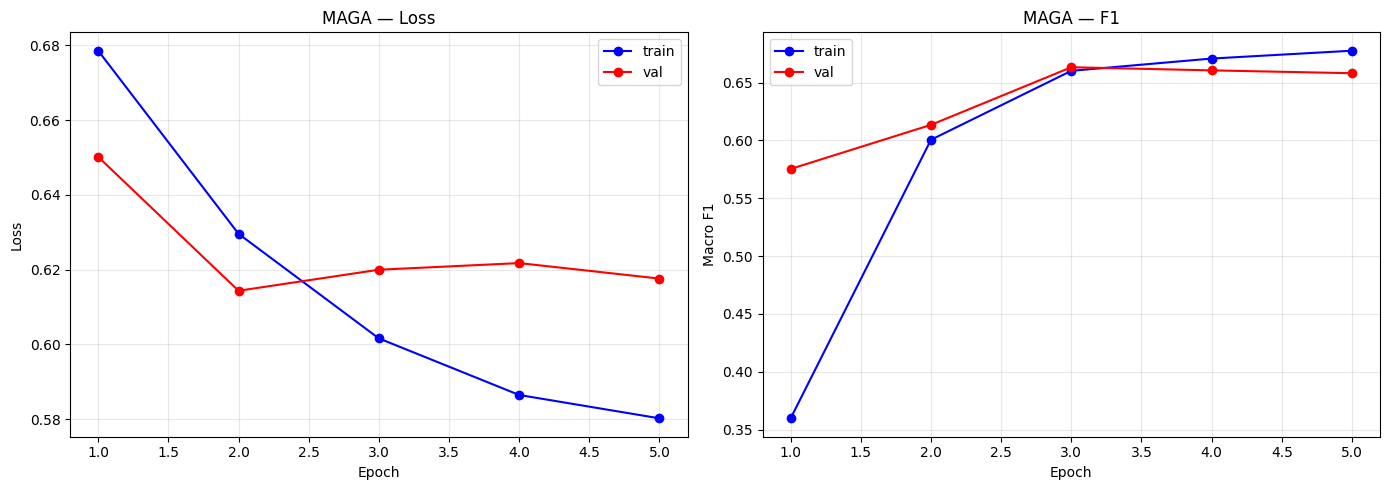

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, maga_hist["train_loss"], "b-o", label="train")
axes[0].plot(epochs, maga_hist["val_loss"],   "r-o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("MAGA  - Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, maga_hist["train_f1"], "b-o", label="train")
axes[1].plot(epochs, maga_hist["val_f1"],   "r-o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].set_title("MAGA  - F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "maga_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [110]:
maga_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "maga_classifier.pt"), map_location=device)
)
maga_model.eval()

maga_preds, maga_labels, maga_gates, maga_divs = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        pv = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        logits = maga_model(pv, ids, mask)
        maga_preds.extend(logits.argmax(dim=1).cpu().numpy())
        maga_labels.extend(batch["label"].numpy())
        g, d = maga_model.get_gate_values(pv, ids, mask)
        maga_gates.extend(g.cpu().numpy())
        maga_divs.extend(d.cpu().numpy())

maga_f1 = f1_score(maga_labels, maga_preds, average="macro")
maga_acc = accuracy_score(maga_labels, maga_preds)

print(f"MAGA  accuracy={maga_acc:.4f}  macro-F1={maga_f1:.4f}")
print(f"mean gate value: {np.mean(maga_gates):.3f}  (0=diverging, 1=aligned)")
print()
print(classification_report(maga_labels, maga_preds,
                             target_names=["Not Hateful", "Hateful"]))

MAGA  accuracy=0.6367  macro-F1=0.6362
mean gate value: 0.314  (0=diverging, 1=aligned)

              precision    recall  f1-score   support

 Not Hateful       0.65      0.60      0.62       150
     Hateful       0.63      0.67      0.65       150

    accuracy                           0.64       300
   macro avg       0.64      0.64      0.64       300
weighted avg       0.64      0.64      0.64       300



In [111]:
dummy_pv = torch.randn(2, 3, 224, 224).to(device)
dummy_ids = torch.randint(0, 1000, (2, 77)).to(device)
dummy_mask = torch.ones(2, 77, dtype=torch.long).to(device)
dummy_lbl = torch.tensor([0, 1]).to(device)

maga_model.train()
out = maga_model(dummy_pv, dummy_ids, dummy_mask)
loss = nn.CrossEntropyLoss()(out, dummy_lbl)
loss.backward()

for name, param in maga_model.named_parameters():
    if "alignment_gate" in name and param.grad is not None:
        print(f"gate grad OK: {name}")

maga_model.eval()

gate grad OK: alignment_gate.gate_network.0.weight
gate grad OK: alignment_gate.gate_network.0.bias
gate grad OK: alignment_gate.gate_network.2.weight
gate grad OK: alignment_gate.gate_network.2.bias


MAGAHateClassifier(
  (clip): CLIPModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=Tru

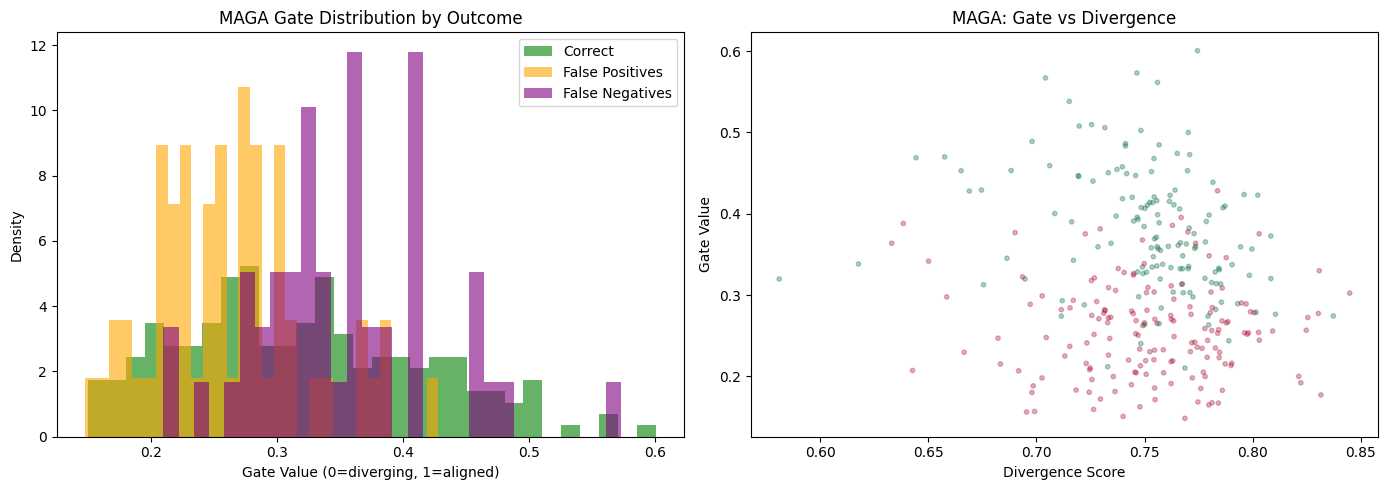

In [112]:
mg = np.array(maga_gates)
ml = np.array(maga_labels)
mp = np.array(maga_preds)
mc = (mp == ml)
mfp = (mp == 1) & (ml == 0)
mfn = (mp == 0) & (ml == 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mg[mc],  bins=30, alpha=0.6, label="Correct",        color="green",  density=True)
if mfp.sum() > 0:
    axes[0].hist(mg[mfp], bins=30, alpha=0.6, label="False Positives", color="orange", density=True)
if mfn.sum() > 0:
    axes[0].hist(mg[mfn], bins=30, alpha=0.6, label="False Negatives", color="purple", density=True)
axes[0].set_xlabel("Gate Value (0=diverging, 1=aligned)"); axes[0].set_ylabel("Density")
axes[0].set_title("MAGA Gate Distribution by Outcome"); axes[0].legend()

axes[1].scatter(np.array(maga_divs), mg, alpha=0.3, s=10, c=mp, cmap="RdYlGn_r")
axes[1].set_xlabel("Divergence Score"); axes[1].set_ylabel("Gate Value")
axes[1].set_title("MAGA: Gate vs Divergence")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "maga_gate_analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Final Comparison Table

In [113]:
final_results = {
    "CLIP Multimodal":  {"Test F1": test_results["f1_macro"], "Accuracy": test_results["accuracy"]},
    "RoBERTa Text-Only":{"Test F1": rr["f1_macro"],           "Accuracy": rr["accuracy"]},
    "CLIP Image-Only":  {"Test F1": img_f1,                   "Accuracy": img_acc},
    "MAGA (Gated)":     {"Test F1": maga_f1,                  "Accuracy": maga_acc},
}
fdf = pd.DataFrame(final_results).T.round(4)
print(fdf.to_string())

                   Test F1  Accuracy
CLIP Multimodal     0.6390    0.6400
RoBERTa Text-Only   0.6260    0.6300
CLIP Image-Only     0.3333    0.5000
MAGA (Gated)        0.6362    0.6367


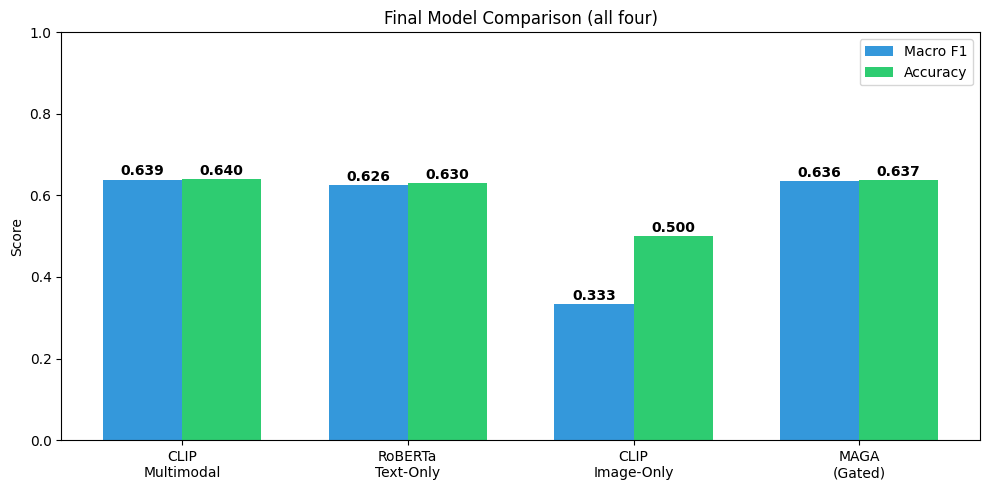

In [114]:
all_models = ["CLIP\nMultimodal", "RoBERTa\nText-Only", "CLIP\nImage-Only", "MAGA\n(Gated)"]
all_f1s = [test_results["f1_macro"], rr["f1_macro"], img_f1, maga_f1]
all_accs = [test_results["accuracy"], rr["accuracy"],  img_acc, maga_acc]

x, w = np.arange(len(all_models)), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, all_f1s,  w, label="Macro F1", color="#3498db")
b2 = ax.bar(x + w/2, all_accs, w, label="Accuracy", color="#2ecc71")
ax.set_ylabel("Score"); ax.set_title("Final Model Comparison (all four)")
ax.set_xticks(x); ax.set_xticklabels(all_models); ax.legend(); ax.set_ylim(0, 1)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "images", "final_model_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Save Results Summary

In [115]:
results_summary = {
    "CLIP": {
        "test_f1":       float(test_results["f1_macro"]),
        "test_accuracy": float(test_results["accuracy"]),
        "f1_per_class":  [float(x) for x in test_results["f1_per_class"]],
    },
    "RoBERTa": {
        "test_f1":       float(rr["f1_macro"]),
        "test_accuracy": float(rr["accuracy"]),
    },
    "Image-Only": {
        "test_f1":       float(img_f1),
        "test_accuracy": float(img_acc),
    },
    "MAGA": {
        "test_f1":       float(maga_f1),
        "test_accuracy": float(maga_acc),
        "mean_gate":     float(np.mean(maga_gates)),
        "mean_divergence": float(np.mean(maga_divs)),
    },
    "Failure Analysis": {
        "false_positive_count": int(len(false_positives)),
        "false_negative_count": int(len(false_negatives)),
        "similarity_auc":  float(auc),
        "mean_sim_fp":     float(false_positives["similarity"].mean()) if len(false_positives) > 0 else 0,
        "mean_sim_fn":     float(false_negatives["similarity"].mean()) if len(false_negatives) > 0 else 0,
        "mean_sim_tp":     float(sims[tp_mask].mean()),
        "mean_sim_tn":     float(sims[tn_mask].mean()),
    },
}

out_path = os.path.join(RESULTS_DIR, "final_results.json")
with open(out_path, "w") as f:
    json.dump(results_summary, f, indent=2)
print(f"results written to {out_path}")

results written to d:\Professors Reached\12- Escalante-Balderas, Hugo\Project\..\results\final_results.json


In [116]:
print("models saved:")
for name in ["clip_classifier.pt", "roberta_classifier.pt",
             "image_only_classifier.pt", "maga_classifier.pt"]:
    path = os.path.join(MODELS_DIR, name)
    size = os.path.getsize(path) / 1e6 if os.path.exists(path) else 0
    print(f"  {name:<35}  {size:.1f} MB")

print()
print("plots saved to:", os.path.join(RESULTS_DIR, "images"))
print("failure CSVs saved to:", os.path.join(RESULTS_DIR, "failure_analysis"))

models saved:
  clip_classifier.pt                   607.9 MB
  roberta_classifier.pt                498.7 MB
  image_only_classifier.pt             605.8 MB
  maga_classifier.pt                   610.0 MB

plots saved to: d:\Professors Reached\12- Escalante-Balderas, Hugo\Project\..\results\images
failure CSVs saved to: d:\Professors Reached\12- Escalante-Balderas, Hugo\Project\..\results\failure_analysis
